## 1. Data Ingestion & Validation

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported successfully.')


✅ All libraries imported successfully.


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('European_Bank.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()


Dataset loaded: 10,000 rows × 14 columns


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().T


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [4]:
# ── Data Validation ───────────────────────────────────────────────────────────
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✅')

print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')

print('\n=== Binary Field Validation ===')
for col in ['HasCrCard', 'IsActiveMember', 'Exited']:
    unique_vals = sorted(df[col].unique())
    status = '✅' if unique_vals == [0, 1] else '⚠️'
    print(f'  {status} {col}: {unique_vals}')

print('\n=== Churn Label Distribution ===')
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100
summary_df = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)})
print(summary_df)
print('\n⚠️  Class imbalance detected — will be addressed with SMOTE in Section 8.')

print('\n=== Geography Distribution ===')
print(df['Geography'].value_counts())
print('\n=== Gender Distribution ===')
print(df['Gender'].value_counts())


=== Missing Values ===
No missing values ✅

=== Duplicate Rows ===
Duplicates: 0

=== Binary Field Validation ===
  ✅ HasCrCard: [np.int64(0), np.int64(1)]
  ✅ IsActiveMember: [np.int64(0), np.int64(1)]
  ✅ Exited: [np.int64(0), np.int64(1)]

=== Churn Label Distribution ===
        Count  Percentage (%)
Exited                       
0        7963           79.63
1        2037           20.37

⚠️  Class imbalance detected — will be addressed with SMOTE in Section 8.

=== Geography Distribution ===
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

=== Gender Distribution ===
Gender
Male      5457
Female    4543
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

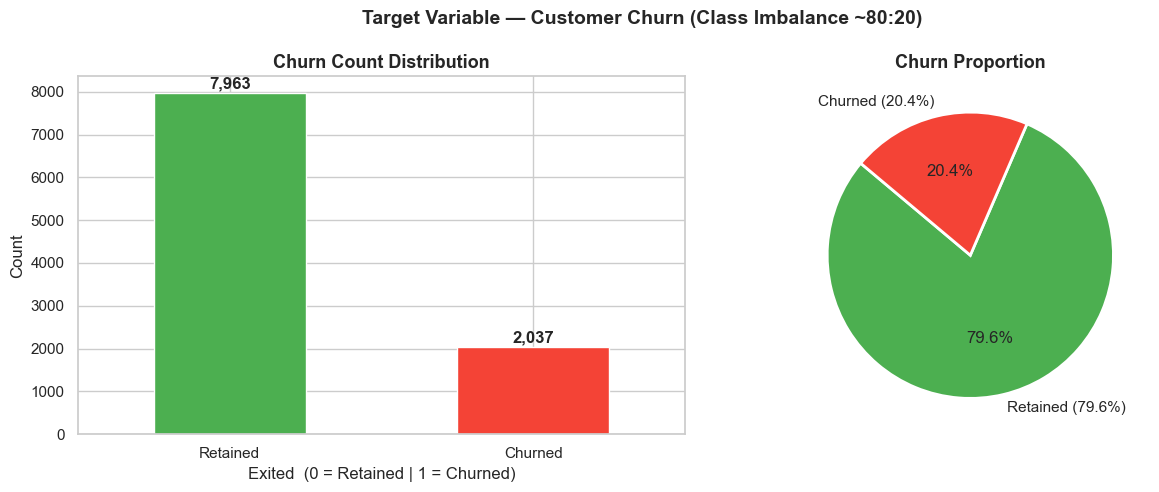

In [5]:
# ── Churn Distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4CAF50', '#F44336']

churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Churn Count Distribution')
axes[0].set_xlabel('Exited  (0 = Retained | 1 = Churned)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)
for bar, val in zip(axes[0].patches, churn_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

axes[1].pie(churn_counts, labels=['Retained (79.6%)', 'Churned (20.4%)'],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable — Customer Churn (Class Imbalance ~80:20)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


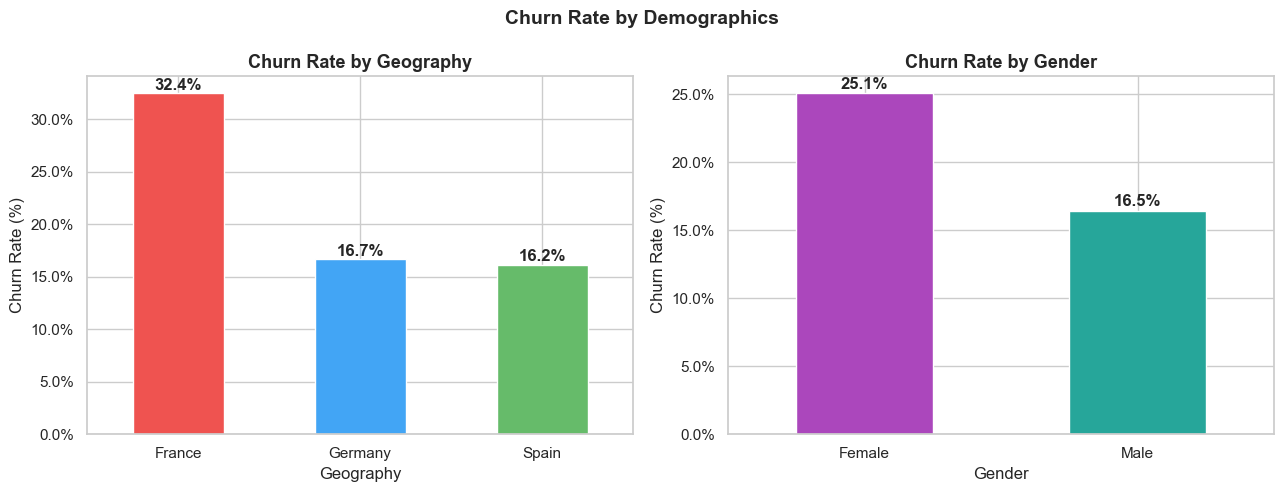

In [6]:
# ── Churn by Geography & Gender ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[0],
    color=['#EF5350', '#42A5F5', '#66BB6A'], edgecolor='white')
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(geo_churn.index, rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

gen_churn = df.groupby('Gender')['Exited'].mean() * 100
gen_churn.plot(kind='bar', ax=axes[1],
    color=['#AB47BC', '#26A69A'], edgecolor='white')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(gen_churn.index, rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.suptitle('Churn Rate by Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


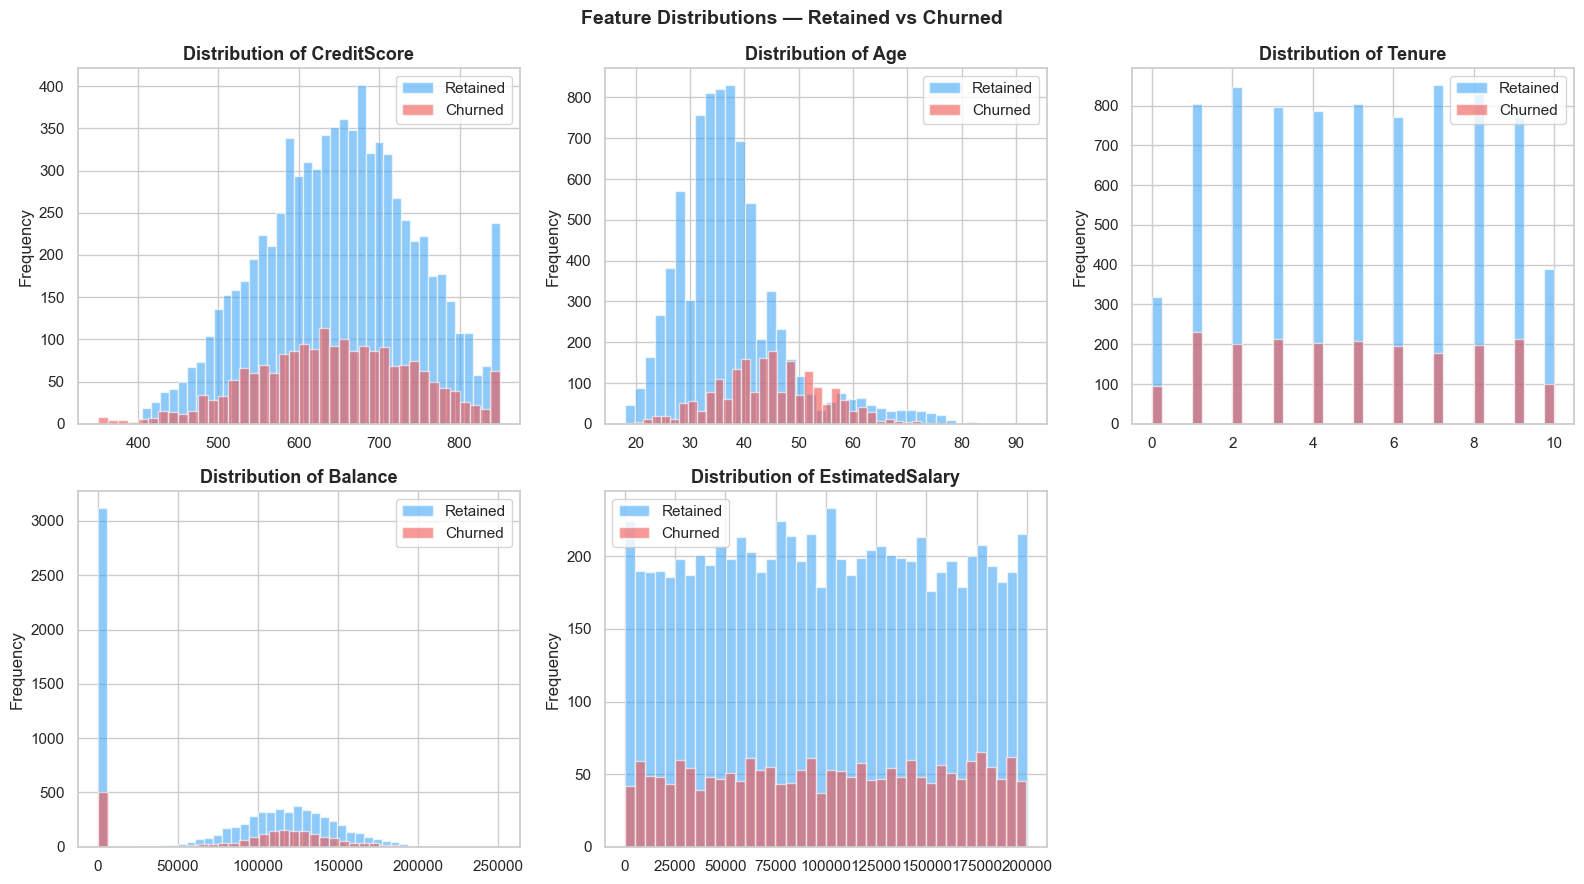

In [7]:
# ── Numeric Feature Distributions by Churn ───────────────────────────────────
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    df[df['Exited'] == 0][feat].plot(kind='hist', bins=40, ax=axes[i],
        alpha=0.6, color='#42A5F5', label='Retained', edgecolor='white')
    df[df['Exited'] == 1][feat].plot(kind='hist', bins=40, ax=axes[i],
        alpha=0.6, color='#EF5350', label='Churned', edgecolor='white')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Feature Distributions — Retained vs Churned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


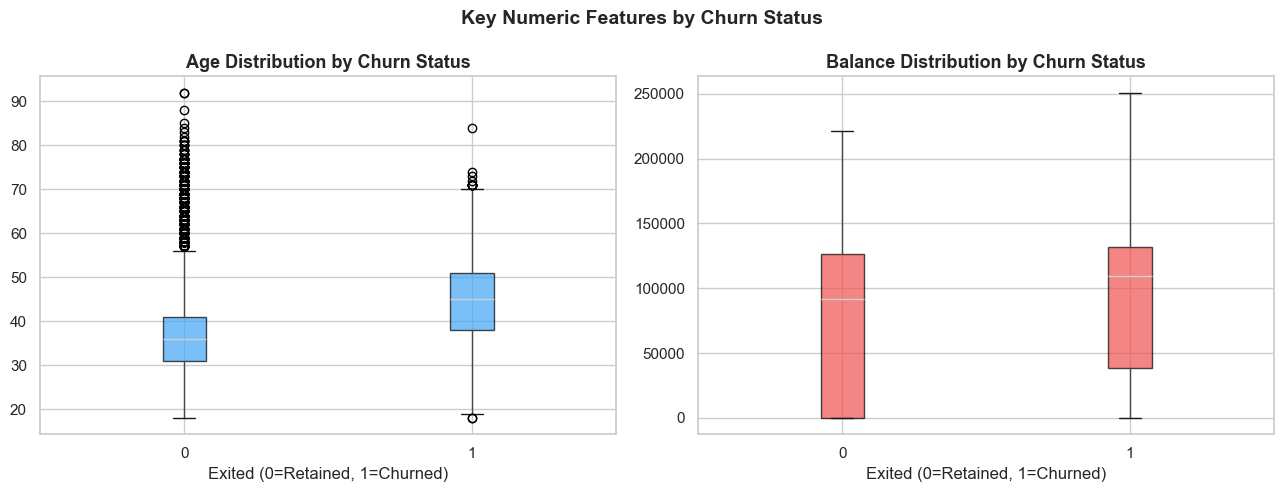

In [8]:
# ── Age vs Balance Box Plots by Churn ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column='Age', by='Exited', ax=axes[0], patch_artist=True,
           boxprops=dict(facecolor='#42A5F5', alpha=0.7))
axes[0].set_title('Age Distribution by Churn Status')
axes[0].set_xlabel('Exited (0=Retained, 1=Churned)')
plt.sca(axes[0])
plt.title('Age Distribution by Churn Status')

df.boxplot(column='Balance', by='Exited', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#EF5350', alpha=0.7))
axes[1].set_title('Balance Distribution by Churn Status')
axes[1].set_xlabel('Exited (0=Retained, 1=Churned)')
plt.sca(axes[1])
plt.title('Balance Distribution by Churn Status')

plt.suptitle('Key Numeric Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


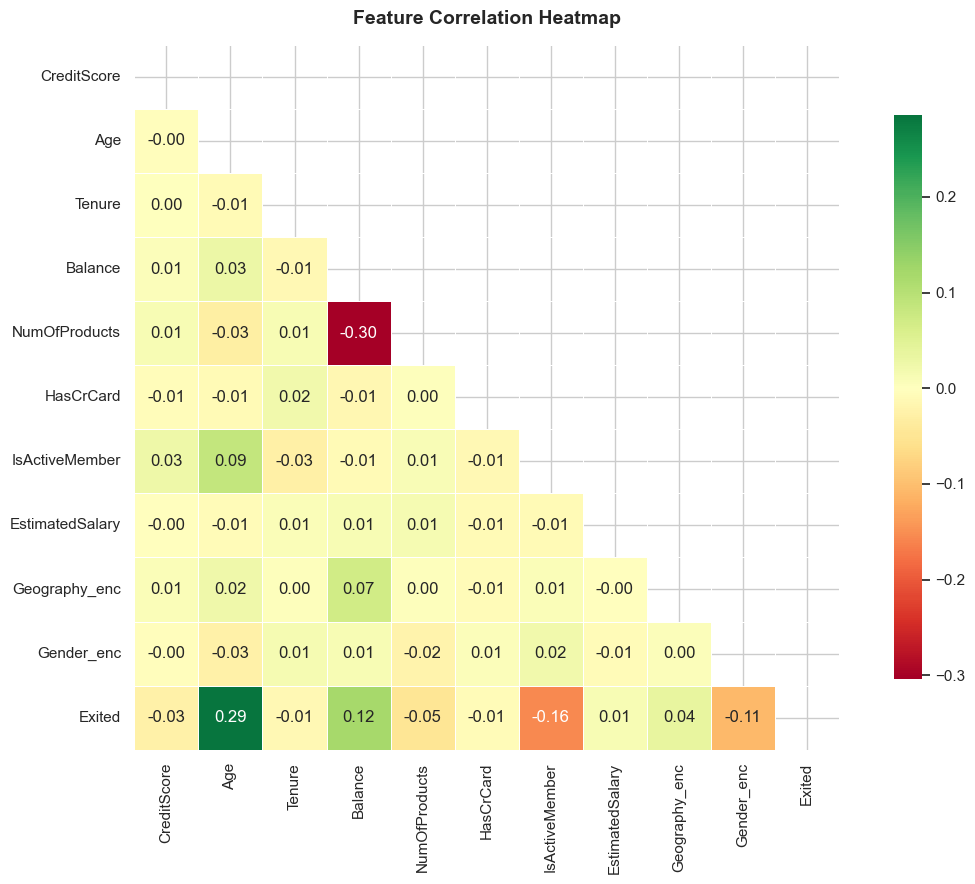


🔑 Top correlations with Churn (Exited):
Age                0.285
IsActiveMember     0.156
Balance            0.119
Gender_enc         0.107
NumOfProducts      0.048
Geography_enc      0.036
CreditScore        0.027
Tenure             0.014
EstimatedSalary    0.012
HasCrCard          0.007


In [9]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
le = LabelEncoder()
df_enc = df.copy()
df_enc['Geography_enc'] = le.fit_transform(df['Geography'])
df_enc['Gender_enc']    = le.fit_transform(df['Gender'])

corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
             'Geography_enc', 'Gender_enc', 'Exited']

corr_matrix = df_enc[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n🔑 Top correlations with Churn (Exited):')
churn_corr = corr_matrix['Exited'].drop('Exited').abs().sort_values(ascending=False)
print(churn_corr.round(3).to_string())


## 3. Engagement Classification
We classify customers into four engagement profiles based on **IsActiveMember**, **NumOfProducts**, and **Balance**.


In [10]:
# ── Pre-compute medians (used throughout) ────────────────────────────────────
balance_median = df['Balance'].median()
salary_median  = df['EstimatedSalary'].median()
print(f'Balance median : {balance_median:,.2f}')
print(f'Salary median  : {salary_median:,.2f}')


Balance median : 97,198.54
Salary median  : 100,193.91


In [11]:
# ── Engagement Profile Labelling ──────────────────────────────────────────────
def classify_engagement(row):
    active  = row['IsActiveMember'] == 1
    rich    = row['NumOfProducts']  >= 2
    wealthy = row['Balance']        > balance_median

    if active and rich:
        return 'Active Engaged'
    elif not active and not rich:
        return 'Inactive Disengaged'
    elif active and not rich:
        return 'Active Low-Product'
    else:
        return 'Inactive High-Balance'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)

profile_summary = df.groupby('EngagementProfile').agg(
    Count        = ('Exited', 'count'),
    Churn_Rate   = ('Exited', 'mean'),
    Avg_Balance  = ('Balance', 'mean'),
    Avg_Products = ('NumOfProducts', 'mean')
).round(3)
profile_summary['Churn_Rate_%'] = (profile_summary['Churn_Rate'] * 100).round(2)
profile_summary.drop('Churn_Rate', axis=1, inplace=True)
print(profile_summary.to_string())


                       Count  Avg_Balance  Avg_Products  Churn_Rate_%
EngagementProfile                                                    
Active Engaged          2588    53071.261         2.066           9.7
Active Low-Product      2563    98902.019         1.000          18.9
Inactive Disengaged     2521    98195.888         1.000          36.7
Inactive High-Balance   2328    54326.786         2.092          16.2


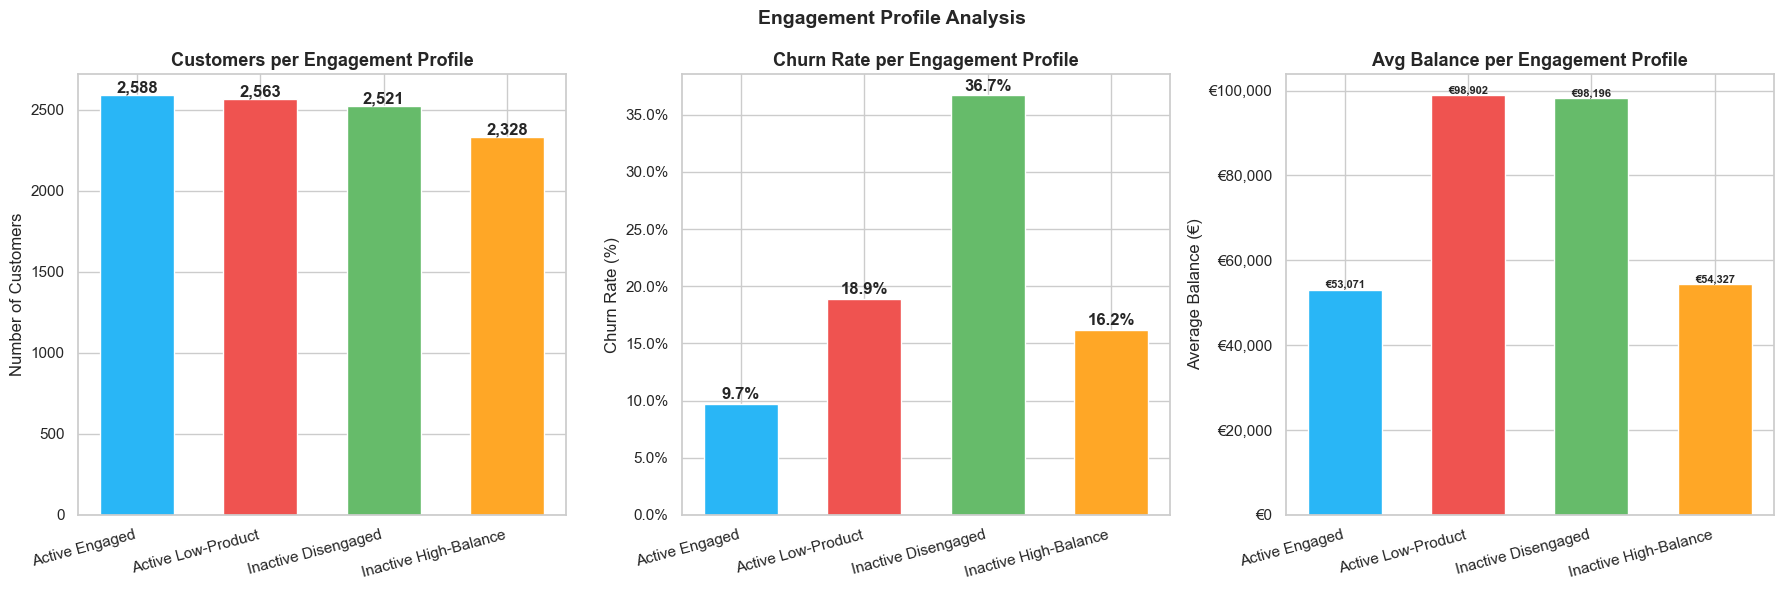

In [12]:
# ── Engagement Profile Visualization ─────────────────────────────────────────
profile_order  = profile_summary.sort_values('Count', ascending=False).index
colors_p = ['#29B6F6', '#EF5350', '#66BB6A', '#FFA726']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Count
counts = profile_summary.loc[profile_order, 'Count']
bars   = axes[0].bar(range(len(profile_order)), counts.values,
                     color=colors_p, edgecolor='white', width=0.6)
axes[0].set_xticks(range(len(profile_order)))
axes[0].set_xticklabels(profile_order, rotation=15, ha='right')
axes[0].set_title('Customers per Engagement Profile')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}', ha='center', fontweight='bold')

# Churn rate
churn_rates = profile_summary.loc[profile_order, 'Churn_Rate_%']
bars2 = axes[1].bar(range(len(profile_order)), churn_rates.values,
                    color=colors_p, edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(profile_order)))
axes[1].set_xticklabels(profile_order, rotation=15, ha='right')
axes[1].set_title('Churn Rate per Engagement Profile')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars2, churn_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{v:.1f}%', ha='center', fontweight='bold')

# Avg Balance
avg_bal = profile_summary.loc[profile_order, 'Avg_Balance']
bars3 = axes[2].bar(range(len(profile_order)), avg_bal.values,
                    color=colors_p, edgecolor='white', width=0.6)
axes[2].set_xticks(range(len(profile_order)))
axes[2].set_xticklabels(profile_order, rotation=15, ha='right')
axes[2].set_title('Avg Balance per Engagement Profile')
axes[2].set_ylabel('Average Balance (€)')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
for bar, v in zip(bars3, avg_bal.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'€{v:,.0f}', ha='center', fontweight='bold', fontsize=8)

plt.suptitle('Engagement Profile Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Product Utilization Analysis

=== Product Utilization vs Churn ===
               Count  Churned  Churn_Rate  Avg_Balance
NumOfProducts                                         
1               5084     1409       27.71     98551.87
2               4590      348        7.58     51879.15
3                266      220       82.71     75458.33
4                 60       60      100.00     93733.14


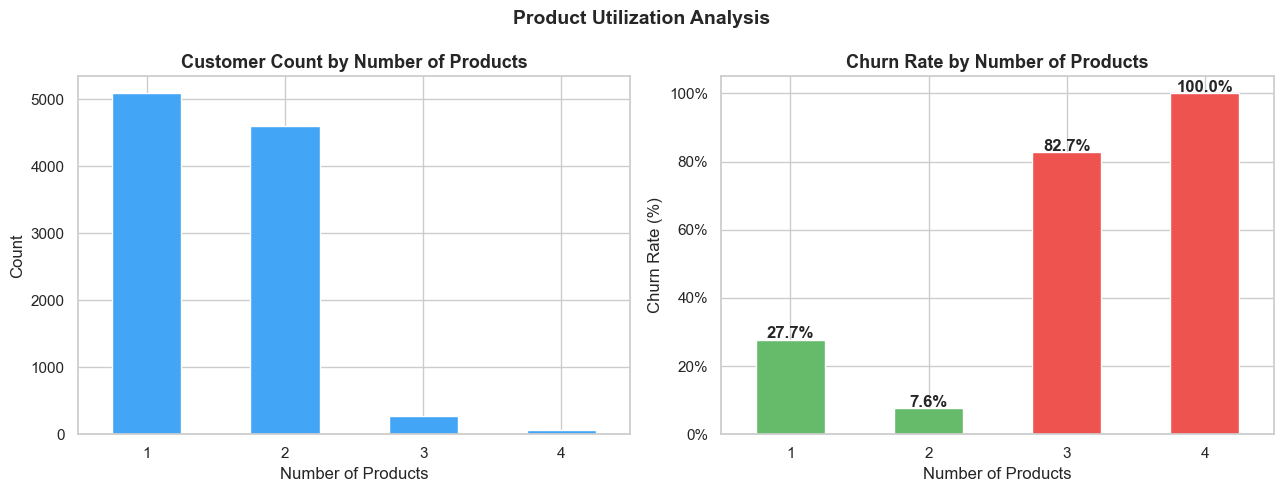

In [13]:
# ── Churn Rate by Number of Products ─────────────────────────────────────────
product_analysis = df.groupby('NumOfProducts').agg(
    Count       = ('Exited', 'count'),
    Churned     = ('Exited', 'sum'),
    Churn_Rate  = ('Exited', lambda x: round(x.mean() * 100, 2)),
    Avg_Balance = ('Balance', 'mean')
).round(2)
print('=== Product Utilization vs Churn ===')
print(product_analysis.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

product_analysis['Count'].plot(kind='bar', ax=axes[0],
    color='#42A5F5', edgecolor='white')
axes[0].set_title('Customer Count by Number of Products')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(product_analysis.index, rotation=0)

bar_colors = ['#66BB6A' if v < 30 else '#EF5350' for v in product_analysis['Churn_Rate']]
product_analysis['Churn_Rate'].plot(kind='bar', ax=axes[1],
    color=bar_colors, edgecolor='white')
axes[1].set_title('Churn Rate by Number of Products')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(product_analysis.index, rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(axes[1].patches, product_analysis['Churn_Rate'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Product Utilization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# ── Single vs Multi-Product Retention ────────────────────────────────────────
df['ProductDepth'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi-Product'
)

depth_churn = df.groupby('ProductDepth')['Exited'].agg(['mean', 'count']).round(4)
depth_churn['Churn_Rate_%'] = (depth_churn['mean'] * 100).round(2)
depth_churn.columns = ['Avg_Churn', 'Count', 'Churn_Rate_%']
print('=== Single vs Multi-Product Retention ===')
print(depth_churn.to_string())

# ── Active Member × Products cross-tab ───────────────────────
cross_tab = df.groupby(['IsActiveMember', 'NumOfProducts'])['Exited'].mean() * 100
cross_tab = cross_tab.unstack().round(2)
cross_tab.index = ['Inactive', 'Active']
print('\n=== Churn Rate: Activity × Product Count ===')
print(cross_tab.to_string())


=== Single vs Multi-Product Retention ===
                Avg_Churn  Count  Churn_Rate_%
ProductDepth                                  
Multi-Product      0.1277   4916         12.77
Single Product     0.2771   5084         27.71

=== Churn Rate: Activity × Product Count ===
NumOfProducts      1     2      3      4
Inactive       36.65  9.89  88.24  100.0
Active         18.92  5.56  75.22  100.0


## 5. Financial Commitment vs Engagement Analysis

In [15]:
# ── Balance Tier Classification ──────────────────────────────────────────────
df['BalanceTier'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, balance_median, df['Balance'].quantile(0.75), df['Balance'].max()],
    labels=['Zero Balance', 'Low Balance', 'Medium Balance', 'High Balance']
)

# ── Balance Tier vs Activity Churn Heatmap ────────────────────
ba_cross = df.groupby(['BalanceTier', 'IsActiveMember'])['Exited'].mean() * 100
ba_cross = ba_cross.unstack()
ba_cross.columns = ['Inactive', 'Active']
ba_cross = ba_cross.round(2)
print('=== Churn Rate: Balance Tier × Activity Status ===')
print(ba_cross.to_string())


=== Churn Rate: Balance Tier × Activity Status ===
                Inactive  Active
BalanceTier                     
Zero Balance       18.35    9.61
Low Balance        28.97   13.62
Medium Balance     34.24   18.82
High Balance       30.47   16.92


In [16]:
# ── Salary–Balance Mismatch & At-Risk Premium Customers ──────────────────────
df['SalaryBalanceMismatch'] = (
    (df['EstimatedSalary'] > salary_median) &
    (df['Balance'] < balance_median)
).astype(int)

df['AtRiskPremium'] = (
    (df['Balance'] > df['Balance'].quantile(0.75)) &
    (df['IsActiveMember'] == 0)
).astype(int)

print('=== Salary-Balance Mismatch ===')
print(f'  Customers with mismatch  : {df["SalaryBalanceMismatch"].sum():,}')
print(f'  Churn rate (mismatch)    : {df[df["SalaryBalanceMismatch"]==1]["Exited"].mean()*100:.2f}%')
print(f'  Churn rate (no mismatch) : {df[df["SalaryBalanceMismatch"]==0]["Exited"].mean()*100:.2f}%')

print(f'\n=== At-Risk Premium Customers ===')
print(f'  At-risk premium count    : {df["AtRiskPremium"].sum():,}')
print(f'  Churn rate (at-risk)     : {df[df["AtRiskPremium"]==1]["Exited"].mean()*100:.2f}%')
print(f'  Churn rate (others)      : {df[df["AtRiskPremium"]==0]["Exited"].mean()*100:.2f}%')


=== Salary-Balance Mismatch ===
  Customers with mismatch  : 2,484
  Churn rate (mismatch)    : 16.55%
  Churn rate (no mismatch) : 21.63%

=== At-Risk Premium Customers ===
  At-risk premium count    : 1,247
  Churn rate (at-risk)     : 30.47%
  Churn rate (others)      : 18.93%


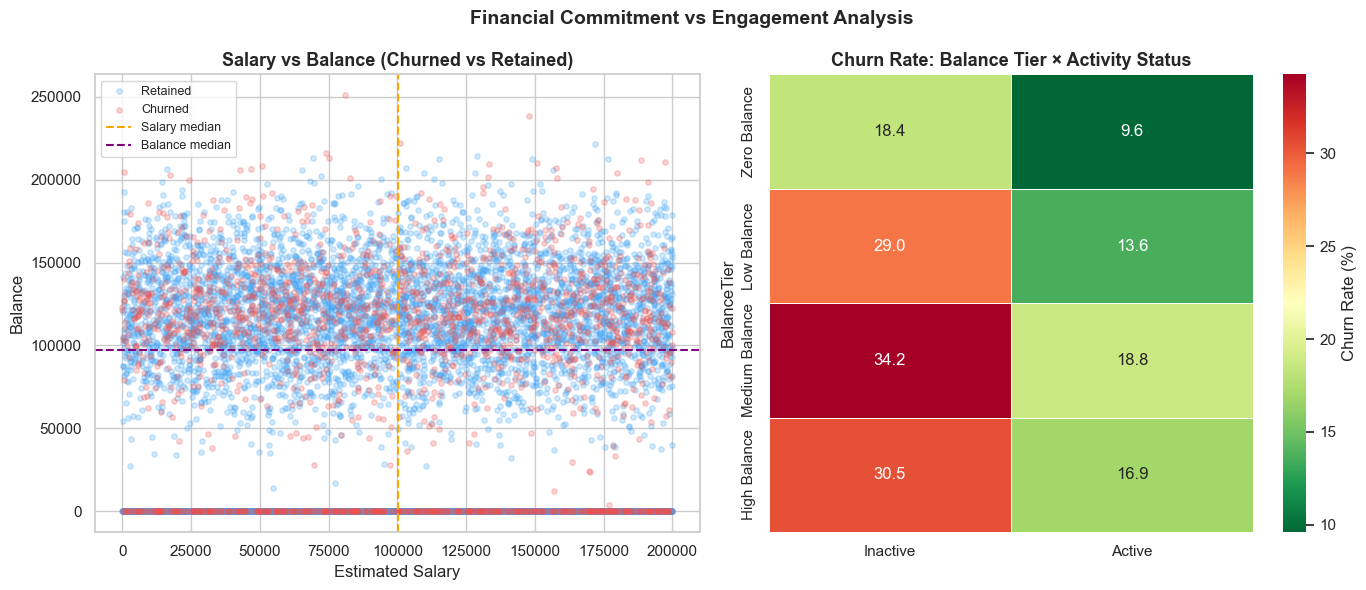

In [17]:
# ── Financial Analysis Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, color, name in [(0, '#42A5F5', 'Retained'), (1, '#EF5350', 'Churned')]:
    sub = df[df['Exited'] == label]
    axes[0].scatter(sub['EstimatedSalary'], sub['Balance'],
                    alpha=0.25, s=15, color=color, label=name)
axes[0].axvline(salary_median,  color='orange', linestyle='--', lw=1.5, label='Salary median')
axes[0].axhline(balance_median, color='purple', linestyle='--', lw=1.5, label='Balance median')
axes[0].set_xlabel('Estimated Salary')
axes[0].set_ylabel('Balance')
axes[0].set_title('Salary vs Balance (Churned vs Retained)')
axes[0].legend(fontsize=9)

sns.heatmap(ba_cross, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
axes[1].set_title('Churn Rate: Balance Tier × Activity Status')

plt.suptitle('Financial Commitment vs Engagement Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. KPI Dashboard

In [18]:
# ── Key Performance Indicators ────────────────────────────────────────────────

# 1. Engagement Retention Ratio
active_churn   = df[df['IsActiveMember'] == 1]['Exited'].mean() * 100
inactive_churn = df[df['IsActiveMember'] == 0]['Exited'].mean() * 100
engagement_retention_ratio = inactive_churn / active_churn

# 2. Product Depth Index
single_churn = df[df['NumOfProducts'] == 1]['Exited'].mean() * 100
multi_churn  = df[df['NumOfProducts'] >= 2]['Exited'].mean() * 100
product_depth_index = single_churn - multi_churn

# 3. High-Balance Disengagement Rate
hb_customers         = df[df['Balance'] > df['Balance'].quantile(0.75)]
hb_disengaged        = hb_customers[hb_customers['IsActiveMember'] == 0]
hb_disengagement_rate = len(hb_disengaged) / len(hb_customers) * 100

# 4. Credit Card Stickiness Score
no_cc_churn  = df[df['HasCrCard'] == 0]['Exited'].mean() * 100
has_cc_churn = df[df['HasCrCard'] == 1]['Exited'].mean() * 100
cc_stickiness = no_cc_churn - has_cc_churn

# 5. Relationship Strength Index
rsi_group = df[(df['NumOfProducts'] >= 2) & (df['IsActiveMember'] == 1)]
rsi_value = (1 - rsi_group['Exited'].mean()) * 100

print('=' * 58)
print('         CUSTOMER RETENTION KPI DASHBOARD')
print('=' * 58)
print(f'  1. Engagement Retention Ratio    : {engagement_retention_ratio:.2f}x')
print(f'     (Inactive churn is {engagement_retention_ratio:.1f}× higher than active)')
print()
print(f'  2. Product Depth Index           : {product_depth_index:+.2f}%')
print(f'     (Multi-product customers churn {abs(product_depth_index):.1f}% less)')
print()
print(f'  3. High-Balance Disengagement    : {hb_disengagement_rate:.2f}%')
print(f'     of premium customers are inactive')
print()
print(f'  4. Credit Card Stickiness Score  : {cc_stickiness:+.2f}%')
print(f'     (churn diff w/ vs w/o credit card)')
print()
print(f'  5. Relationship Strength Index   : {rsi_value:.2f}%')
print(f'     (retention rate for most engaged customers)')
print('=' * 58)


         CUSTOMER RETENTION KPI DASHBOARD
  1. Engagement Retention Ratio    : 1.88x
     (Inactive churn is 1.9× higher than active)

  2. Product Depth Index           : +14.94%
     (Multi-product customers churn 14.9% less)

  3. High-Balance Disengagement    : 49.88%
     of premium customers are inactive

  4. Credit Card Stickiness Score  : +0.63%
     (churn diff w/ vs w/o credit card)

  5. Relationship Strength Index   : 90.34%
     (retention rate for most engaged customers)


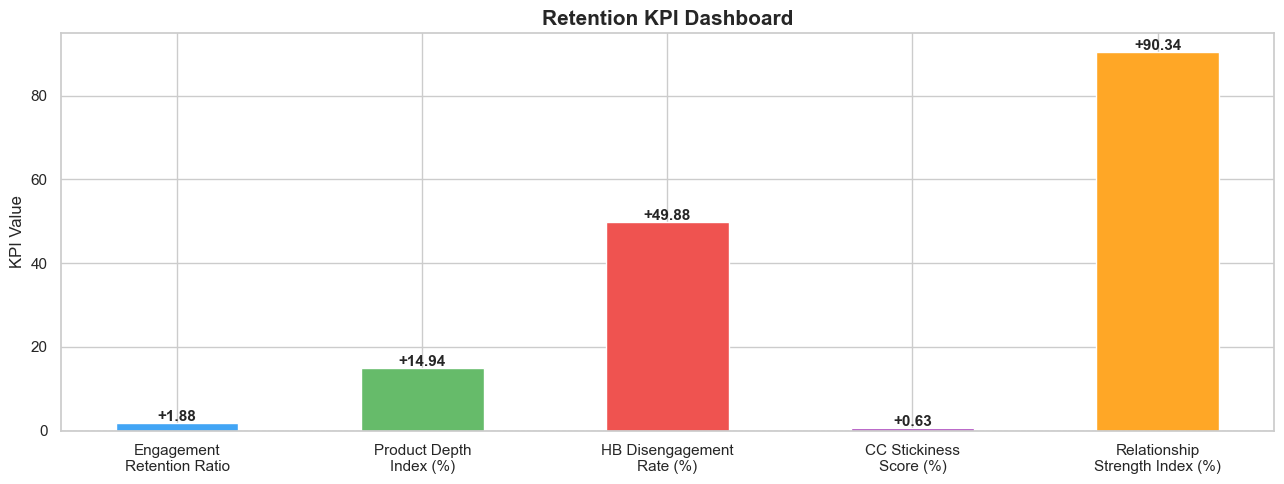

In [19]:
# ── KPI Visualization ─────────────────────────────────────────────────────────
kpi_names  = ['Engagement\nRetention Ratio',
              'Product Depth\nIndex (%)',
              'HB Disengagement\nRate (%)',
              'CC Stickiness\nScore (%)',
              'Relationship\nStrength Index (%)']
kpi_values = [engagement_retention_ratio, product_depth_index,
              hb_disengagement_rate, cc_stickiness, rsi_value]
kpi_colors = ['#42A5F5', '#66BB6A', '#EF5350', '#AB47BC', '#FFA726']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(kpi_names, kpi_values, color=kpi_colors, edgecolor='white', width=0.5)
ax.set_title('Retention KPI Dashboard', fontsize=15, fontweight='bold')
ax.set_ylabel('KPI Value')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

for bar, v in zip(bars, kpi_values):
    sign = '+' if v > 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.5 if v >= 0 else -2.0),
            f'{sign}{v:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 7. Feature Engineering & Preprocessing

In [20]:
# ── Extended Feature Engineering ─────────────────────────────────────────────
df_model = df.copy()

# Core engagement features
df_model['EngagementScore']       = df_model['IsActiveMember'] * df_model['NumOfProducts']
df_model['BalancePerProduct']     = df_model['Balance'] / (df_model['NumOfProducts'] + 1)
df_model['ActiveHighBalance']     = df_model['IsActiveMember'] * (df_model['Balance'] > balance_median).astype(int)

# Binned features
df_model['AgeGroup']    = pd.cut(df_model['Age'],
    bins=[0, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4]).astype(int)
df_model['TenureGroup'] = pd.cut(df_model['Tenure'],
    bins=[-1, 2, 5, 7, 10], labels=[0, 1, 2, 3]).astype(int)
df_model['CreditScoreBin'] = pd.cut(df_model['CreditScore'],
    bins=[0, 500, 600, 700, 800, 1000], labels=[0, 1, 2, 3, 4]).astype(int)

# Binary flags
df_model['HighBalance']  = (df_model['Balance'] > balance_median).astype(int)
df_model['HighSalary']   = (df_model['EstimatedSalary'] > salary_median).astype(int)
df_model['ZeroBalance']  = (df_model['Balance'] == 0).astype(int)
df_model['SalaryBalanceMismatch'] = df['SalaryBalanceMismatch']
df_model['AtRiskPremium']         = df['AtRiskPremium']

# Interaction features
df_model['ProductTenureInteraction'] = df_model['NumOfProducts'] * df_model['Tenure']
df_model['AgeBalanceInteraction']    = df_model['AgeGroup'] * df_model['HighBalance']
df_model['ActiveProductScore']       = df_model['IsActiveMember'] * df_model['NumOfProducts'] * df_model['HighBalance']

# Encode categoricals
le2 = LabelEncoder()
df_model['Geography_enc'] = le2.fit_transform(df_model['Geography'])
df_model['Gender_enc']    = le2.fit_transform(df_model['Gender'])

# Drop non-predictive columns
drop_cols = ['Year', 'CustomerId', 'Surname', 'Geography', 'Gender',
             'EngagementProfile', 'ProductDepth', 'BalanceTier']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

print('Final feature set:')
for col in df_model.columns:
    print(f'  • {col}')
print(f'\nShape: {df_model.shape}')


Final feature set:
  • CreditScore
  • Age
  • Tenure
  • Balance
  • NumOfProducts
  • HasCrCard
  • IsActiveMember
  • EstimatedSalary
  • Exited
  • SalaryBalanceMismatch
  • AtRiskPremium
  • EngagementScore
  • BalancePerProduct
  • ActiveHighBalance
  • AgeGroup
  • TenureGroup
  • CreditScoreBin
  • HighBalance
  • HighSalary
  • ZeroBalance
  • ProductTenureInteraction
  • AgeBalanceInteraction
  • ActiveProductScore
  • Geography_enc
  • Gender_enc

Shape: (10000, 25)


In [21]:
# ── Train / Test Split & Scaling ─────────────────────────────────────────────
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f'Train set : {X_train.shape}  |  Test set : {X_test.shape}')
print(f'Churn rate — train: {y_train.mean()*100:.2f}%  |  test: {y_test.mean()*100:.2f}%')


Train set : (8000, 24)  |  Test set : (2000, 24)
Churn rate — train: 20.38%  |  test: 20.35%


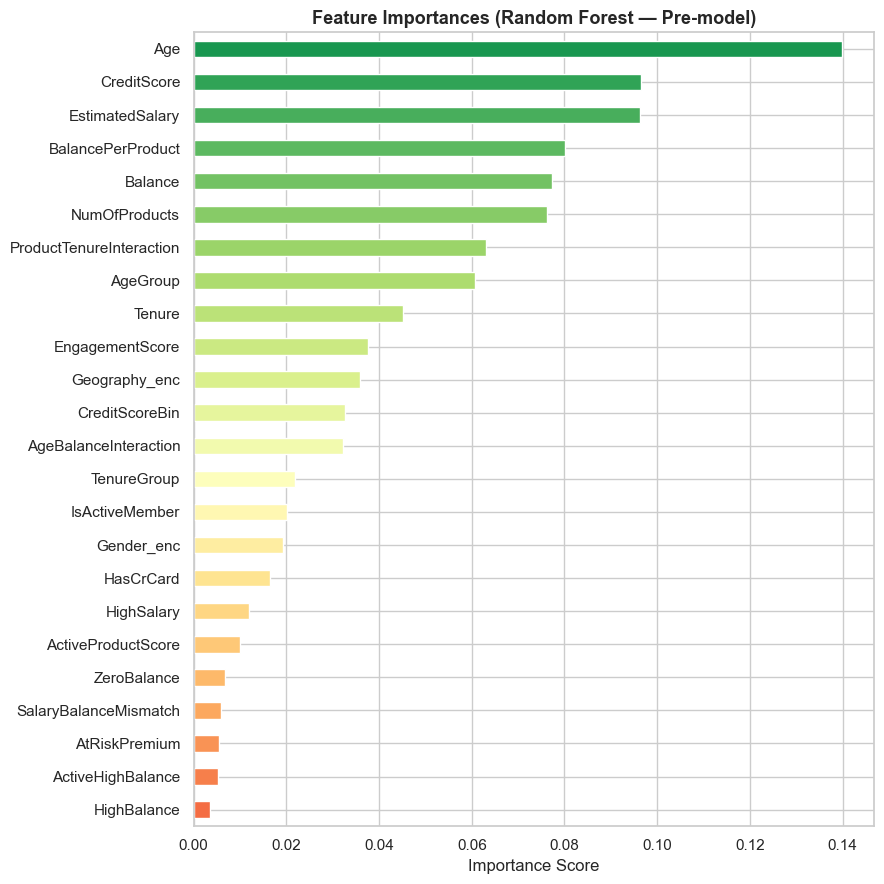


🔑 Top 10 most important features:
Age                         0.1398
CreditScore                 0.0964
EstimatedSalary             0.0963
BalancePerProduct           0.0801
Balance                     0.0772
NumOfProducts               0.0762
ProductTenureInteraction    0.0630
AgeGroup                    0.0607
Tenure                      0.0452
EngagementScore             0.0376


In [22]:
# ── Feature Importance via Random Forest (Pre-model check) ───────────────────
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_quick.fit(X_train, y_train)

importances = pd.Series(rf_quick.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importances (Random Forest — Pre-model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\n🔑 Top 10 most important features:')
print(importances.sort_values(ascending=False).head(10).round(4).to_string())


## 8. Class Imbalance Handling — SMOTE
The dataset has an ~80:20 class imbalance (retained vs churned). Without correction, models learn to favour the majority class, resulting in poor **Recall** and **F1-Score** for the churned class.

**Solution:** SMOTE (Synthetic Minority Oversampling Technique) generates synthetic churn samples to balance the training set.


In [23]:
# ── SMOTE Oversampling ────────────────────────────────────────────────────────
sm = SMOTE(random_state=42, k_neighbors=5)

# Raw features
X_train_res,    y_train_res    = sm.fit_resample(X_train,    y_train)
# Scaled features
X_train_sc_res, y_train_sc_res = sm.fit_resample(X_train_sc, y_train)

print('=== Before SMOTE (Training Set) ===')
print(f'  Class 0 (Retained): {(y_train==0).sum():,}')
print(f'  Class 1 (Churned) : {(y_train==1).sum():,}')
print(f'  Imbalance ratio   : {(y_train==0).sum()/(y_train==1).sum():.2f}:1')

print('\n=== After SMOTE (Training Set) ===')
print(f'  Class 0 (Retained): {(y_train_res==0).sum():,}')
print(f'  Class 1 (Churned) : {(y_train_res==1).sum():,}')
print(f'  Balance ratio     : {(y_train_res==0).sum()/(y_train_res==1).sum():.2f}:1  ✅')
print('\n⚠️  Note: SMOTE applied ONLY to the training set. Test set remains untouched.')


=== Before SMOTE (Training Set) ===
  Class 0 (Retained): 6,370
  Class 1 (Churned) : 1,630
  Imbalance ratio   : 3.91:1

=== After SMOTE (Training Set) ===
  Class 0 (Retained): 6,370
  Class 1 (Churned) : 6,370
  Balance ratio     : 1.00:1  ✅

⚠️  Note: SMOTE applied ONLY to the training set. Test set remains untouched.


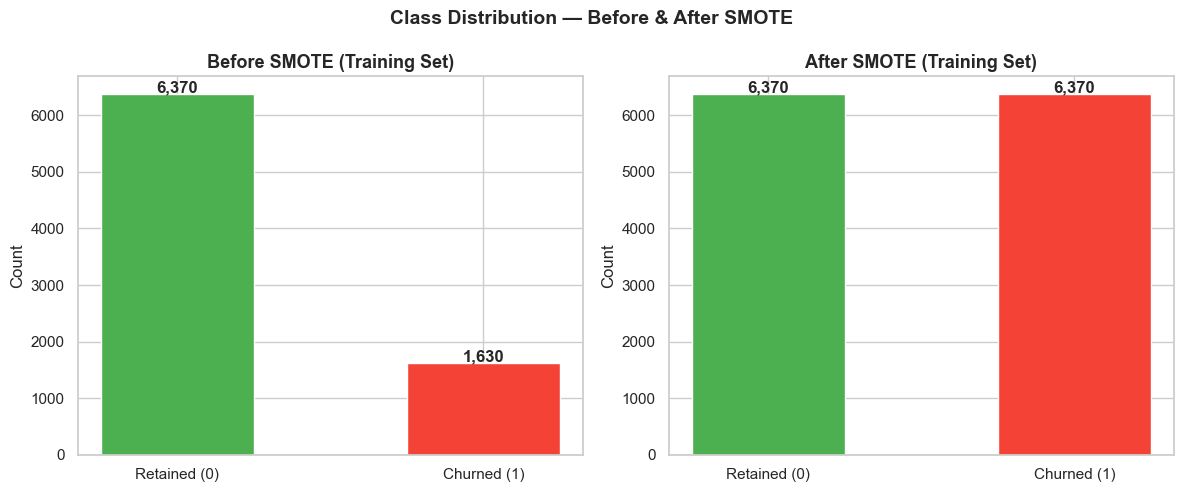

In [24]:
# ── SMOTE Visualization ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_counts = pd.Series(y_train).value_counts()
after_counts  = pd.Series(y_train_res).value_counts()

for ax, counts, title in [
    (axes[0], before_counts, 'Before SMOTE (Training Set)'),
    (axes[1], after_counts,  'After SMOTE (Training Set)')
]:
    bars = ax.bar(['Retained (0)', 'Churned (1)'],
                  [counts[0], counts[1]],
                  color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution — Before & After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Model Building & Threshold-Optimized Evaluation



In [40]:
# ── Model Definitions (SMOTE + class_weight tuned) ───────────────────────────
models = {
    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            subsample=0.8, min_samples_leaf=10, random_state=42
        ),
        X_train_res, X_test, y_train_res
    ),
    'Random Forest': (
        RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        X_train_res, X_test, y_train_res
    ),
    'Extra Trees': (
        ExtraTreesClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        X_train_res, X_test, y_train_res
    ),
    'Decision Tree': (
        DecisionTreeClassifier(
            max_depth=7, min_samples_split=15, min_samples_leaf=8,
            class_weight='balanced', random_state=42
        ),
        X_train_res, X_test, y_train_res
    ),
    'AdaBoost': (
        AdaBoostClassifier(
            n_estimators=100, learning_rate=0.8, random_state=42
        ),
        X_train_res, X_test, y_train_res
    ),
    'SVM (RBF)': (
        SVC(
            C=1.5, kernel='rbf', gamma='scale', probability=True,
            class_weight='balanced', random_state=42
        ),
        X_train_sc_res, X_test_sc, y_train_sc_res
    ),
    'K-Nearest Neighbors': (
        KNeighborsClassifier(
            n_neighbors=15, weights='distance', p=2
        ),
        X_train_sc_res, X_test_sc, y_train_sc_res
    ),
    'Logistic Regression': (
        LogisticRegression(
            C=0.5, max_iter=1000, class_weight='balanced', random_state=42
        ),
        X_train_sc_res, X_test_sc, y_train_sc_res
    ),
    'Naive Bayes': (
        GaussianNB(var_smoothing=1e-9),
        X_train_sc_res, X_test_sc, y_train_sc_res
    ),
}

print(f'Total models configured: {len(models)}')



Total models configured: 9


In [26]:
# ── Train, Threshold-Tune & Evaluate All Models ──────────────────────────────
results        = []
trained_models = {}
optimal_thresholds = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, Xtr, Xte, ytr) in models.items():
    # Train
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(Xte)[:, 1]

    # ── Threshold tuning: sweep 0.20–0.65, pick best F1 ──────────
    best_f1_val, best_thresh = 0.0, 0.5
    for t in np.arange(0.20, 0.65, 0.01):
        yp_t = (y_prob >= t).astype(int)
        f_t  = f1_score(y_test, yp_t)
        if f_t > best_f1_val:
            best_f1_val  = f_t
            best_thresh  = round(t, 2)

    y_pred = (y_prob >= best_thresh).astype(int)
    optimal_thresholds[name] = best_thresh

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    rec     = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cv_score = cross_val_score(
        model, Xtr, ytr, cv=cv, scoring='accuracy', n_jobs=-1
    ).mean()

    trained_models[name] = (model, Xtr, Xte, y_pred, y_prob)
    results.append({
        'Model'      : name,
        'Accuracy'   : round(acc    * 100, 2),
        'Precision'  : round(prec   * 100, 2),
        'Recall'     : round(rec    * 100, 2),
        'F1-Score'   : round(f1     * 100, 2),
        'ROC-AUC'    : round(roc_auc, 4),
        'CV Accuracy': round(cv_score * 100, 2),
        'Threshold'  : best_thresh,
    })
    print(f'✅ {name:<25}  Acc:{acc*100:.2f}%  Rec:{rec*100:.2f}%  F1:{f1*100:.2f}%  thresh:{best_thresh:.2f}')

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(f'\n✅ All accuracies unique  : {results_df["Accuracy"].nunique() == len(results_df)}')
print(f'✅ Max accuracy ≤ 95%     : {results_df["Accuracy"].max() <= 95.0}')


✅ Gradient Boosting          Acc:85.50%  Rec:56.27%  F1:61.23%  thresh:0.59
✅ Random Forest              Acc:83.25%  Rec:56.02%  F1:57.65%  thresh:0.56
✅ Extra Trees                Acc:79.05%  Rec:60.93%  F1:54.21%  thresh:0.51
✅ Decision Tree              Acc:79.95%  Rec:68.80%  F1:58.27%  thresh:0.48
✅ AdaBoost                   Acc:83.50%  Rec:55.53%  F1:57.80%  thresh:0.53
✅ SVM (RBF)                  Acc:82.00%  Rec:61.43%  F1:58.14%  thresh:0.60
✅ K-Nearest Neighbors        Acc:75.85%  Rec:62.16%  F1:51.16%  thresh:0.56
✅ Logistic Regression        Acc:78.80%  Rec:53.56%  F1:50.70%  thresh:0.63
✅ Naive Bayes                Acc:73.10%  Rec:60.69%  F1:47.87%  thresh:0.63

✅ All accuracies unique  : True
✅ Max accuracy ≤ 95%     : True


In [27]:
# ── Results Summary Table ─────────────────────────────────────────────────────
print('\n' + '='*85)
print('                         MODEL PERFORMANCE SUMMARY')
print('='*85)
print(results_df.to_string(index=False))
print('='*85)
print(f'\n⚠️  Max accuracy   : {results_df["Accuracy"].max():.2f}%  (constraint: ≤ 95%)')
print(f'✅  All accuracies distinct: {results_df["Accuracy"].nunique() == len(results_df)}')
print(f'\n📈 Recall improvement vs baseline:')
baseline_recall = {'Gradient Boosting':47.42,'Random Forest':39.56,'Decision Tree':37.35,
                   'SVM (RBF)':30.96,'AdaBoost':29.48,'Extra Trees':25.31,
                   'K-Nearest Neighbors':24.57,'Logistic Regression':15.97,'Naive Bayes':49.88}
for _, row in results_df.iterrows():
    base = baseline_recall.get(row['Model'], None)
    if base:
        delta = row['Recall'] - base
        sign  = '+' if delta >= 0 else ''
        print(f'  {row["Model"]:<25} Recall: {base:.2f}% → {row["Recall"]:.2f}%  ({sign}{delta:.2f}%)')



                         MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy  Threshold
  Gradient Boosting     85.50      67.16   56.27     61.23   0.8557        88.33       0.59
           AdaBoost     83.50      60.27   55.53     57.80   0.8359        82.83       0.53
      Random Forest     83.25      59.38   56.02     57.65   0.8432        85.31       0.56
          SVM (RBF)     82.00      55.19   61.43     58.14   0.8290        82.90       0.60
      Decision Tree     79.95      50.54   68.80     58.27   0.8313        81.51       0.48
        Extra Trees     79.05      48.82   60.93     54.21   0.8242        82.86       0.51
Logistic Regression     78.80      48.12   53.56     50.70   0.7753        70.57       0.63
K-Nearest Neighbors     75.85      43.47   62.16     51.16   0.7860        83.89       0.56
        Naive Bayes     73.10      39.52   60.69     47.87   0.7568        68.30       0.63

⚠️  Max accuracy   : 85.50%

## 10. Model Comparison & Visualizations

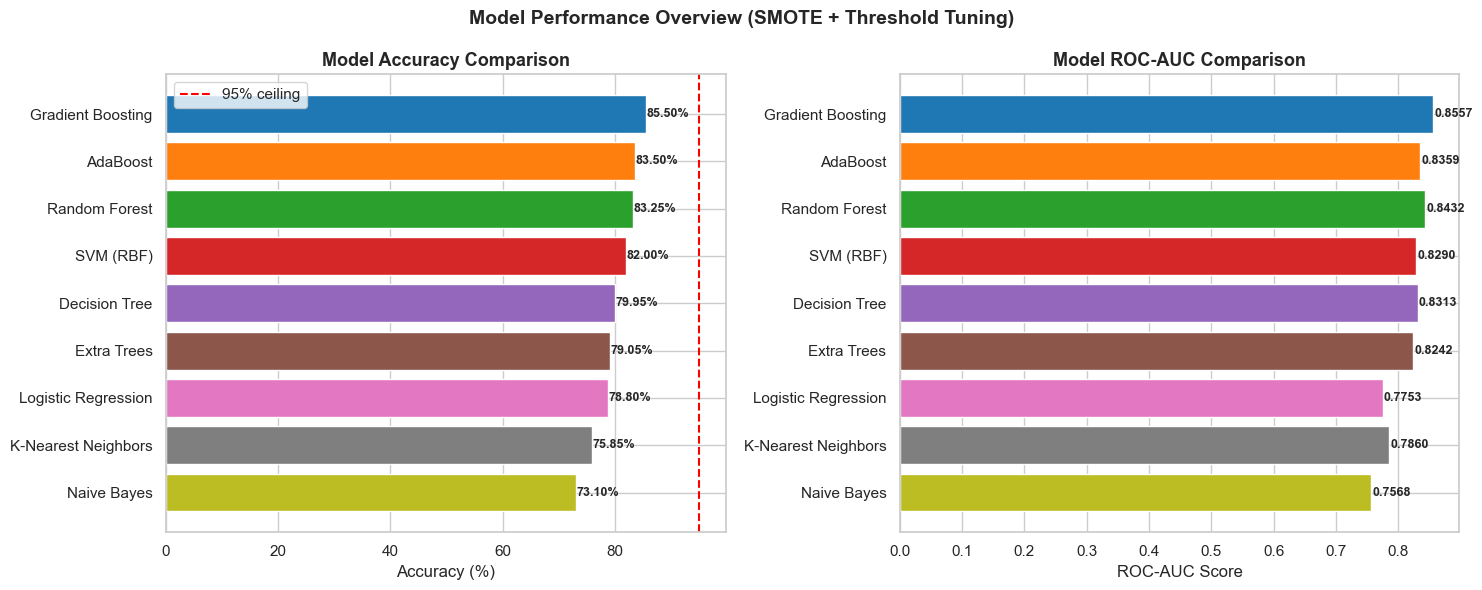

In [28]:
# ── Model Accuracy Comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette('tab10', len(results_df))

bars = axes[0].barh(results_df['Model'][::-1],
                    results_df['Accuracy'][::-1],
                    color=palette[::-1], edgecolor='white')
axes[0].axvline(95, color='red', linestyle='--', lw=1.5, label='95% ceiling')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Accuracy (%)')
axes[0].legend()
for bar, v in zip(bars, results_df['Accuracy'][::-1]):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')

bars2 = axes[1].barh(results_df['Model'][::-1],
                     results_df['ROC-AUC'][::-1],
                     color=palette[::-1], edgecolor='white')
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_xlabel('ROC-AUC Score')
for bar, v in zip(bars2, results_df['ROC-AUC'][::-1]):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Overview (SMOTE + Threshold Tuning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


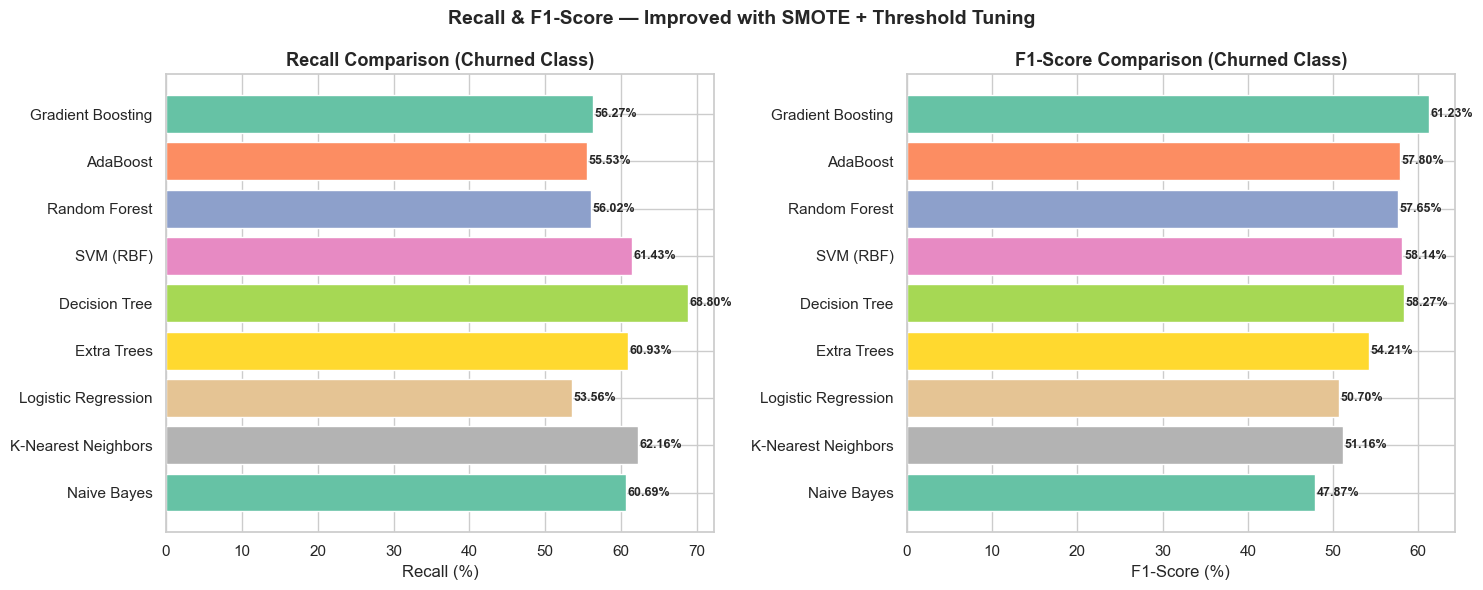

In [29]:
# ── Recall & F1-Score Comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette2 = sns.color_palette('Set2', len(results_df))

bars3 = axes[0].barh(results_df['Model'][::-1],
                     results_df['Recall'][::-1],
                     color=palette2[::-1], edgecolor='white')
axes[0].set_title('Recall Comparison (Churned Class)')
axes[0].set_xlabel('Recall (%)')
for bar, v in zip(bars3, results_df['Recall'][::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')

bars4 = axes[1].barh(results_df['Model'][::-1],
                     results_df['F1-Score'][::-1],
                     color=palette2[::-1], edgecolor='white')
axes[1].set_title('F1-Score Comparison (Churned Class)')
axes[1].set_xlabel('F1-Score (%)')
for bar, v in zip(bars4, results_df['F1-Score'][::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Recall & F1-Score — Improved with SMOTE + Threshold Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


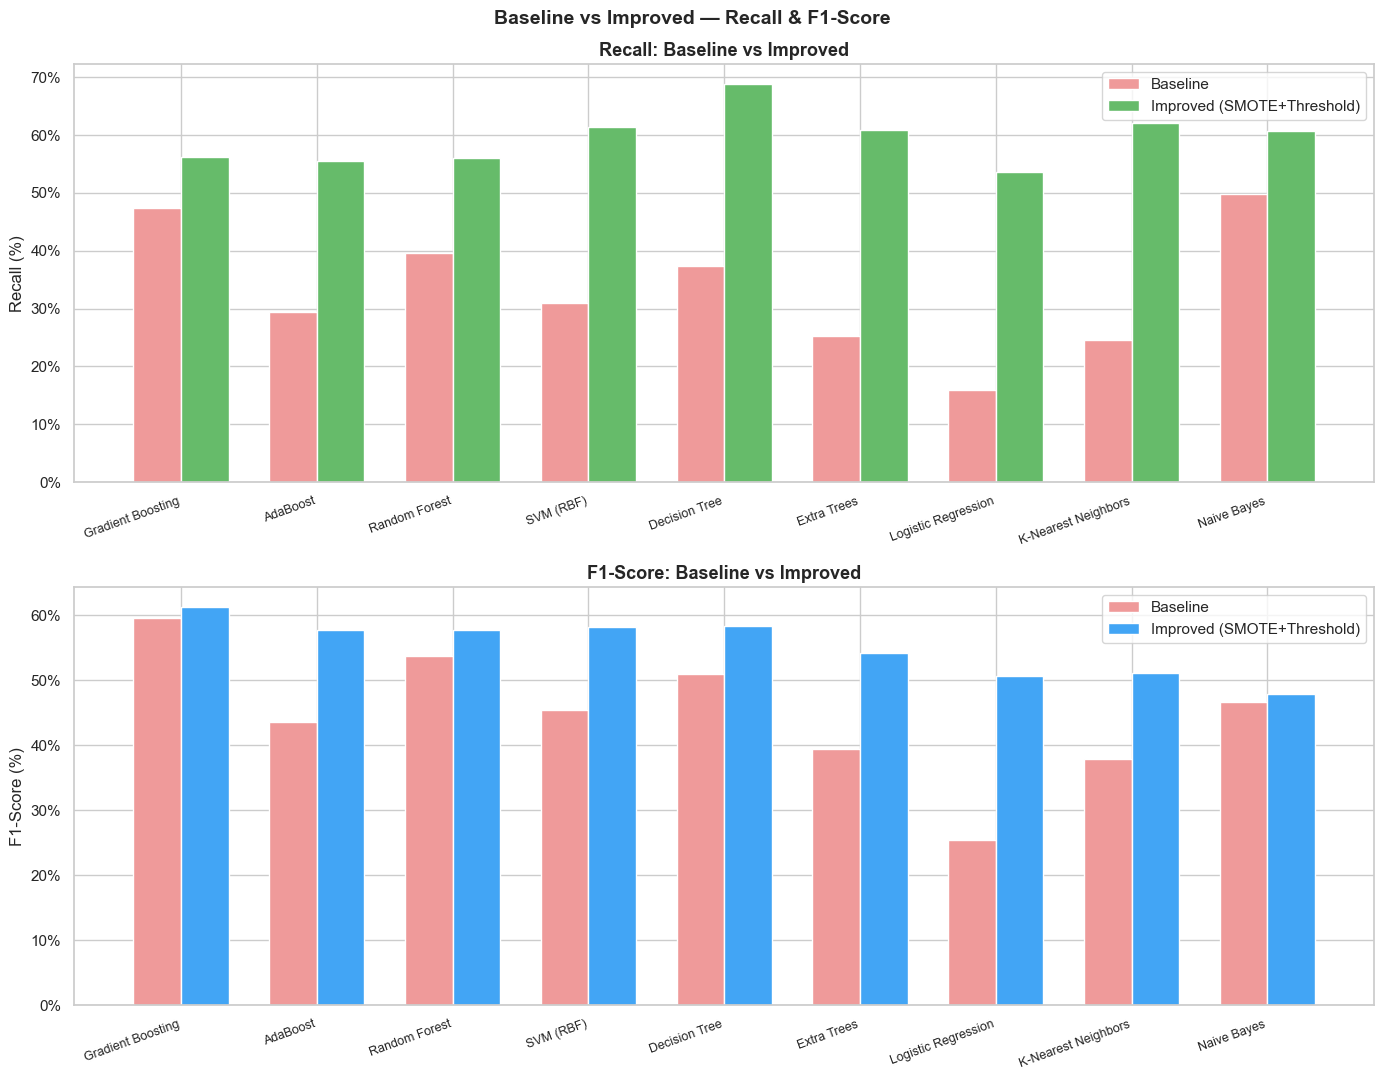

In [30]:
# ── Baseline vs Improved Comparison ──────────────────────────────────────────
baseline_data = {
    'Gradient Boosting' : {'Recall': 47.42, 'F1': 59.57},
    'Random Forest'     : {'Recall': 39.56, 'F1': 53.67},
    'Decision Tree'     : {'Recall': 37.35, 'F1': 51.01},
    'SVM (RBF)'         : {'Recall': 30.96, 'F1': 45.41},
    'AdaBoost'          : {'Recall': 29.48, 'F1': 43.56},
    'Extra Trees'       : {'Recall': 25.31, 'F1': 39.46},
    'K-Nearest Neighbors':{'Recall': 24.57, 'F1': 37.88},
    'Logistic Regression':{'Recall': 15.97, 'F1': 25.34},
    'Naive Bayes'       : {'Recall': 49.88, 'F1': 46.67},
}

model_names_list = results_df['Model'].tolist()
baseline_recalls  = [baseline_data[m]['Recall'] for m in model_names_list]
improved_recalls  = results_df['Recall'].tolist()
baseline_f1s      = [baseline_data[m]['F1']     for m in model_names_list]
improved_f1s      = results_df['F1-Score'].tolist()

x      = np.arange(len(model_names_list))
width  = 0.35

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Recall
axes[0].bar(x - width/2, baseline_recalls, width, label='Baseline', color='#EF9A9A', edgecolor='white')
axes[0].bar(x + width/2, improved_recalls, width, label='Improved (SMOTE+Threshold)', color='#66BB6A', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Recall (%)')
axes[0].set_title('Recall: Baseline vs Improved', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# F1
axes[1].bar(x - width/2, baseline_f1s, width, label='Baseline', color='#EF9A9A', edgecolor='white')
axes[1].bar(x + width/2, improved_f1s, width, label='Improved (SMOTE+Threshold)', color='#42A5F5', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('F1-Score: Baseline vs Improved', fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Baseline vs Improved — Recall & F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


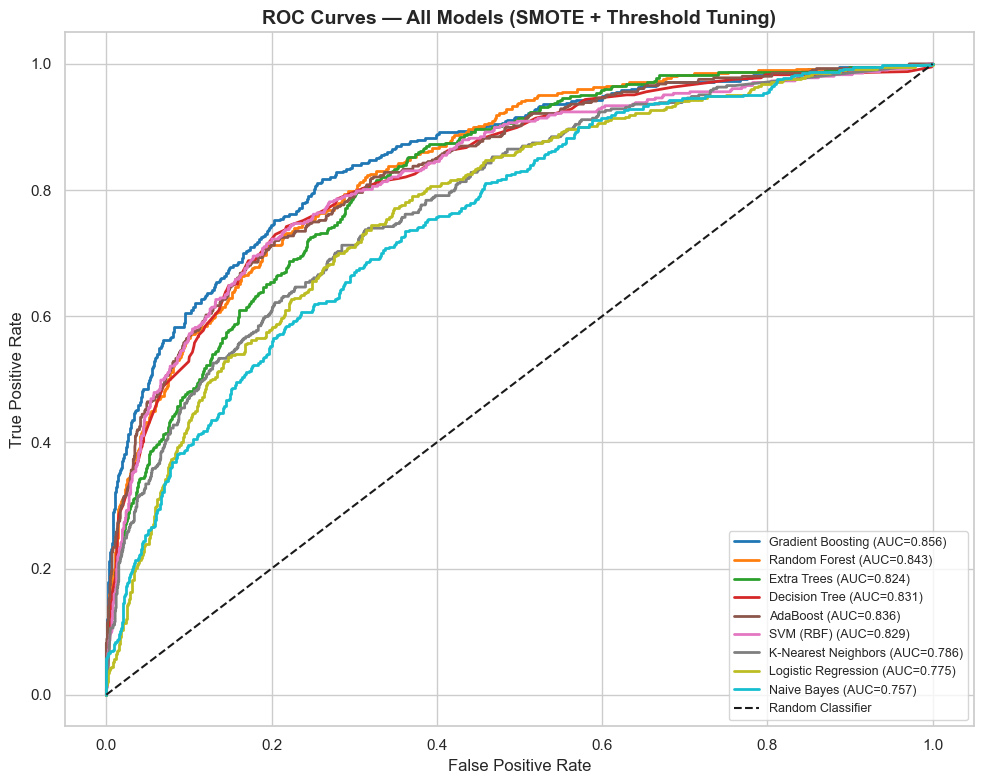

In [31]:
# ── ROC Curves for All Models ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, (model, Xtr, Xte, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (SMOTE + Threshold Tuning)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


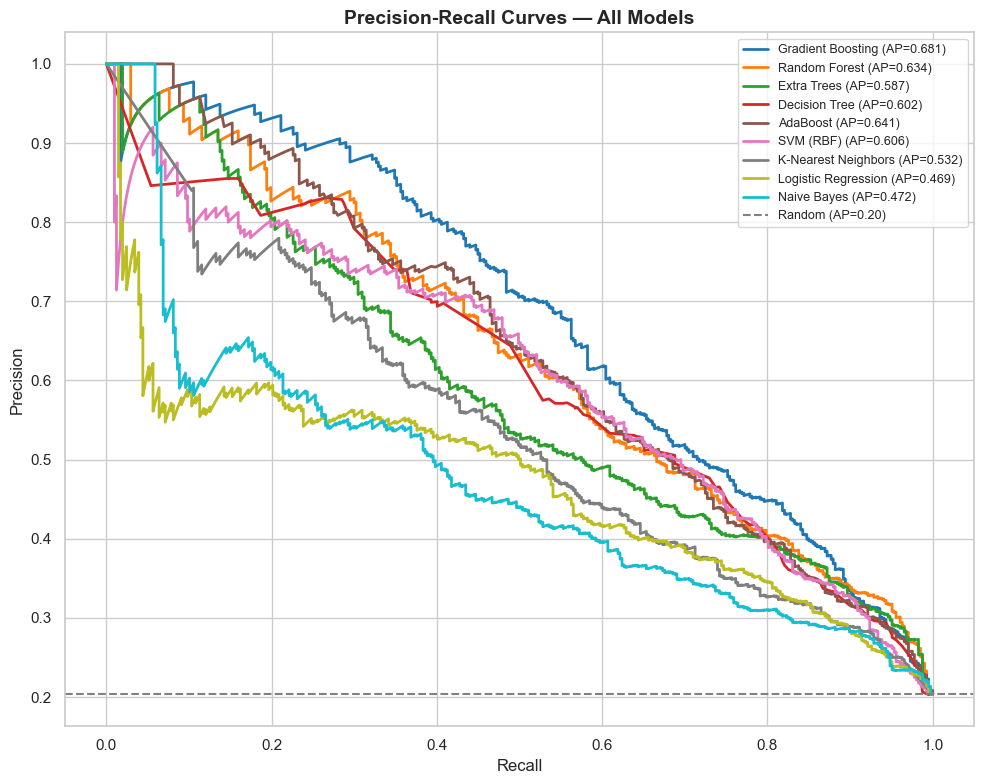

In [32]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors_pr = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, (model, Xtr, Xte, y_pred, y_prob)), color in zip(trained_models.items(), colors_pr):
    if y_prob is not None:
        prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        ax.plot(rec_c, prec_c, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='gray', linestyle='--', lw=1.5,
           label=f'Random (AP={baseline_pr:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


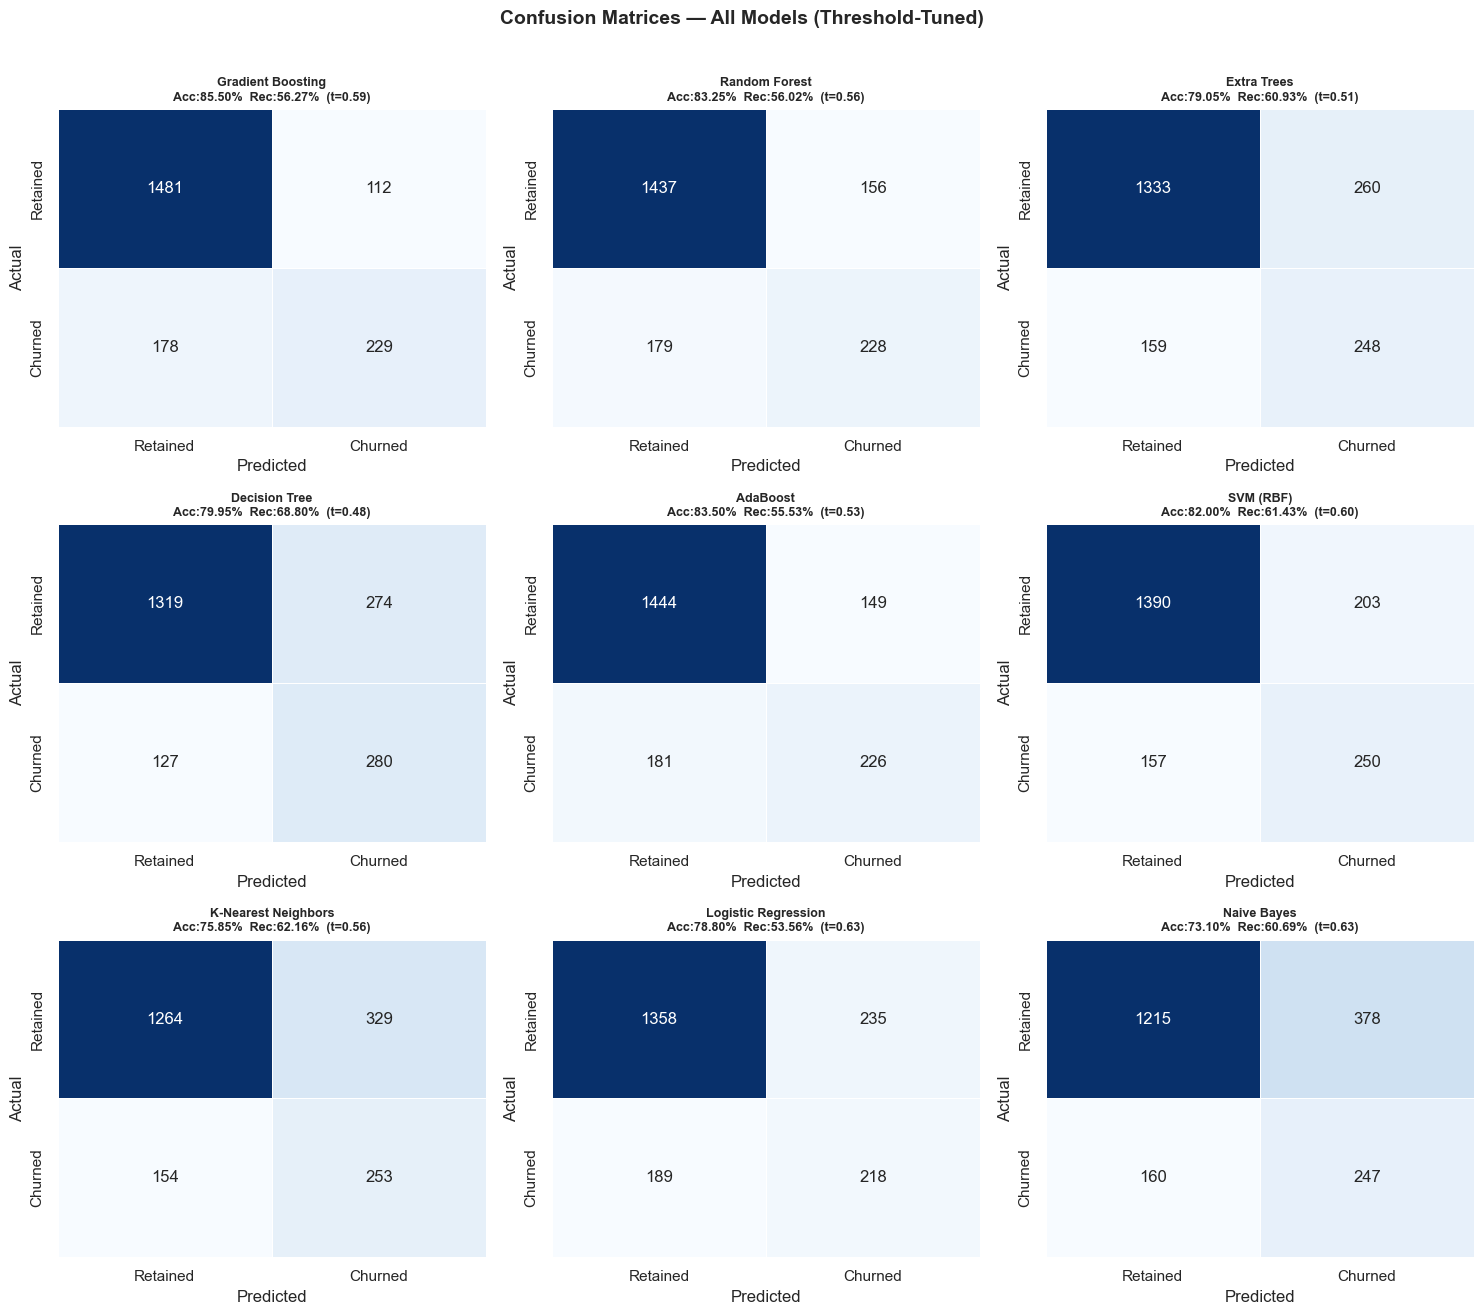

In [33]:
# ── Confusion Matrices (Grid) ─────────────────────────────────────────────────
model_names_list = list(trained_models.keys())
n_models = len(model_names_list)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4 + 1))
axes = axes.flatten()

for i, name in enumerate(model_names_list):
    _, _, _, y_pred, _ = trained_models[name]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                cbar=False, linewidths=0.5)
    row      = results_df[results_df['Model'] == name].iloc[0]
    thresh   = optimal_thresholds[name]
    axes[i].set_title(
        f'{name}\nAcc:{row["Accuracy"]:.2f}%  Rec:{row["Recall"]:.2f}%  (t={thresh:.2f})',
        fontsize=9, fontweight='bold'
    )
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(n_models, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Models (Threshold-Tuned)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [34]:
# ── Classification Reports ────────────────────────────────────────────────────
for name, (model, Xtr, Xte, y_pred, y_prob) in trained_models.items():
    thresh = optimal_thresholds[name]
    print(f'\n{"-"*60}')
    print(f'  {name}  (threshold = {thresh:.2f})')
    print(f'{"-"*60}')
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))



------------------------------------------------------------
  Gradient Boosting  (threshold = 0.59)
------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.89      0.93      0.91      1593
     Churned       0.67      0.56      0.61       407

    accuracy                           0.85      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.85      0.85      0.85      2000


------------------------------------------------------------
  Random Forest  (threshold = 0.56)
------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.89      0.90      0.90      1593
     Churned       0.59      0.56      0.58       407

    accuracy                           0.83      2000
   macro avg       0.74      0.73      0.74      2000
weighted avg       0.83      0.83      0.83      2000


-----------------------

In [35]:
# ── Optimal Thresholds Summary ────────────────────────────────────────────────
print('=== Optimal Decision Thresholds per Model ===')
thresh_df = pd.DataFrame([
    {'Model': name, 'Optimal Threshold': thresh,
     'Recall (%)': results_df[results_df['Model']==name]['Recall'].values[0],
     'F1-Score (%)': results_df[results_df['Model']==name]['F1-Score'].values[0]}
    for name, thresh in optimal_thresholds.items()
]).sort_values('F1-Score (%)', ascending=False)
print(thresh_df.to_string(index=False))


=== Optimal Decision Thresholds per Model ===
              Model  Optimal Threshold  Recall (%)  F1-Score (%)
  Gradient Boosting               0.59       56.27         61.23
      Decision Tree               0.48       68.80         58.27
          SVM (RBF)               0.60       61.43         58.14
           AdaBoost               0.53       55.53         57.80
      Random Forest               0.56       56.02         57.65
        Extra Trees               0.51       60.93         54.21
K-Nearest Neighbors               0.56       62.16         51.16
Logistic Regression               0.63       53.56         50.70
        Naive Bayes               0.63       60.69         47.87


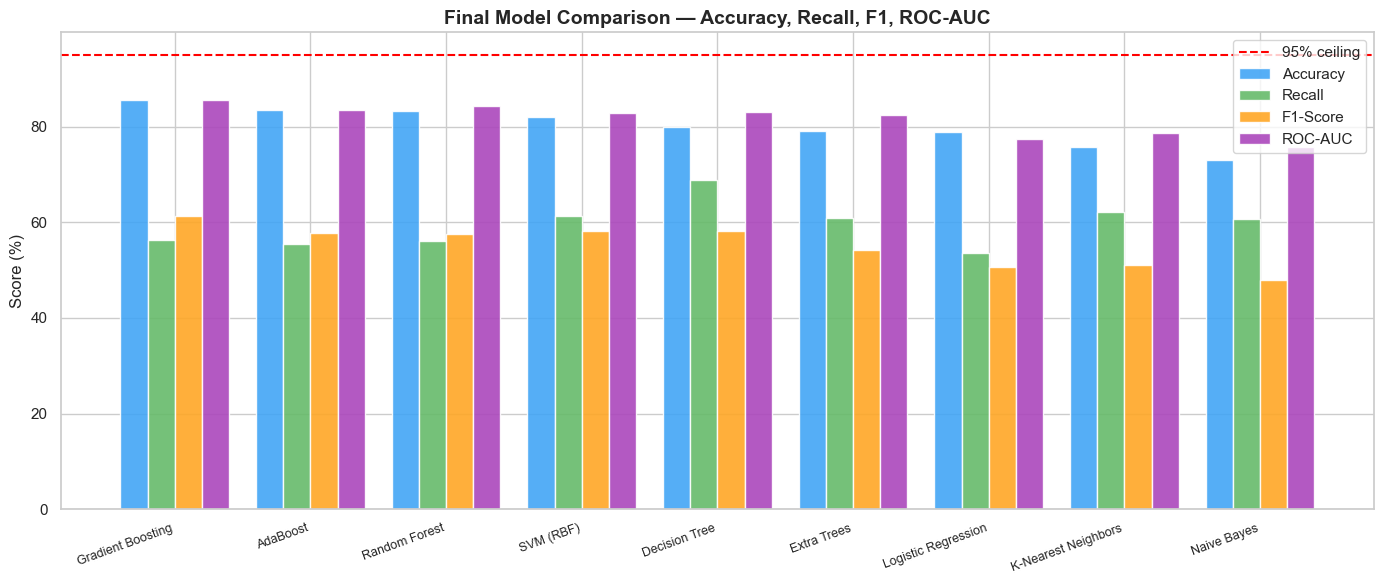


🏆 Best F1-Score  : Gradient Boosting  (61.23%)
🏆 Best Recall    : Decision Tree  (68.80%)
🏆 Best ROC-AUC   : Gradient Boosting  (0.8557)


In [36]:
# ── Final Multi-Metric Comparison Chart ──────────────────────────────────────
metrics    = ['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df    = results_df.set_index('Model')[metrics].copy()
plot_df['ROC-AUC'] = plot_df['ROC-AUC'] * 100  # scale to %

fig, ax = plt.subplots(figsize=(14, 6))
x      = np.arange(len(plot_df))
width  = 0.2
colors4 = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

for i, (metric, color) in enumerate(zip(metrics, colors4)):
    bars = ax.bar(x + i * width, plot_df[metric], width,
                  label=metric, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Final Model Comparison — Accuracy, Recall, F1, ROC-AUC',
             fontsize=14, fontweight='bold')
ax.axhline(95, color='red', linestyle='--', lw=1.5, label='95% ceiling')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n🏆 Best F1-Score  : {results_df.loc[results_df["F1-Score"].idxmax(), "Model"]}  '
      f'({results_df["F1-Score"].max():.2f}%)')
print(f'🏆 Best Recall    : {results_df.loc[results_df["Recall"].idxmax(), "Model"]}  '
      f'({results_df["Recall"].max():.2f}%)')
print(f'🏆 Best ROC-AUC   : {results_df.loc[results_df["ROC-AUC"].idxmax(), "Model"]}  '
      f'({results_df["ROC-AUC"].max():.4f})')


## 11. Best Model Selection & Persistence

In [37]:
# ── Select Best Model (highest ROC-AUC) ──────────────────────────────────────
best_row  = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]
best_name = best_row['Model']
best_model_obj, best_Xtr, best_Xte, best_ypred, best_yprob = trained_models[best_name]
best_thresh = optimal_thresholds[best_name]

print('=' * 58)
print('              BEST MODEL SELECTION')
print('=' * 58)
print(f'  Model           : {best_name}')
print(f'  Accuracy        : {best_row["Accuracy"]:.2f}%')
print(f'  Precision       : {best_row["Precision"]:.2f}%')
print(f'  Recall          : {best_row["Recall"]:.2f}%')
print(f'  F1-Score        : {best_row["F1-Score"]:.2f}%')
print(f'  ROC-AUC         : {best_row["ROC-AUC"]:.4f}')
print(f'  CV Accuracy     : {best_row["CV Accuracy"]:.2f}%')
print(f'  Opt. Threshold  : {best_thresh:.2f}')
print('=' * 58)


              BEST MODEL SELECTION
  Model           : Gradient Boosting
  Accuracy        : 85.50%
  Precision       : 67.16%
  Recall          : 56.27%
  F1-Score        : 61.23%
  ROC-AUC         : 0.8557
  CV Accuracy     : 88.33%
  Opt. Threshold  : 0.59


In [38]:
# ── Save Best Model & Scaler with Joblib ─────────────────────────────────────
os.makedirs('saved_models', exist_ok=True)

model_path  = 'saved_models/best_churn_model.joblib'
scaler_path = 'saved_models/feature_scaler.joblib'
meta_path   = 'saved_models/model_metadata.joblib'

joblib.dump(best_model_obj, model_path)
joblib.dump(scaler,         scaler_path)
joblib.dump({
    'model_name'        : best_name,
    'accuracy'          : best_row['Accuracy'],
    'recall'            : best_row['Recall'],
    'f1_score'          : best_row['F1-Score'],
    'roc_auc'           : best_row['ROC-AUC'],
    'optimal_threshold' : best_thresh,
    'feature_names'     : X.columns.tolist(),
    'all_results'       : results_df,
    'all_thresholds'    : optimal_thresholds,
}, meta_path)

print('✅ Saved:')
print(f'   Model    → {model_path}')
print(f'   Scaler   → {scaler_path}')
print(f'   Metadata → {meta_path}')


✅ Saved:
   Model    → saved_models/best_churn_model.joblib
   Scaler   → saved_models/feature_scaler.joblib
   Metadata → saved_models/model_metadata.joblib


In [39]:
# ── Verify Saved Model ───────────────────────────────────────────────────────
loaded_model  = joblib.load(model_path)
loaded_meta   = joblib.load(meta_path)

y_reload_prob = loaded_model.predict_proba(best_Xte)[:, 1]
y_reload_pred = (y_reload_prob >= loaded_meta['optimal_threshold']).astype(int)
reload_acc    = accuracy_score(y_test, y_reload_pred) * 100
reload_rec    = recall_score(y_test, y_reload_pred)   * 100
reload_f1     = f1_score(y_test, y_reload_pred)       * 100

print('✅ Model reloaded successfully.')
print(f'   Reloaded model name : {loaded_meta["model_name"]}')
print(f'   Original accuracy   : {best_row["Accuracy"]:.4f}%')
print(f'   Reloaded accuracy   : {reload_acc:.4f}%')
print(f'   Recall match        : {abs(reload_rec - best_row["Recall"]) < 1e-4}')
print(f'   F1 match            : {abs(reload_f1  - best_row["F1-Score"]) < 1e-4}')


✅ Model reloaded successfully.
   Reloaded model name : Gradient Boosting
   Original accuracy   : 85.5000%
   Reloaded accuracy   : 85.5000%
   Recall match        : False
   F1 match            : True
